**GOALS**
* Self-Attention, Multi-Head Self-Attention x
* Layer Normalization x
* Feed-forward layer+Network x
* Residual Connections x
* Positional Encodings
* different types of Attention: Softmax Attention, Linear Attention
* bonus: Attention Residuals
* transformer blocks: masks
* Linear Algebra Review

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import math

#### Single Head Attention

In [17]:
class SingleHeadAttention(nn.Module):
    def __init__(self, hidden_size,d_k):
        super().__init__()
        self.d_k = d_k
        self.q_proj = nn.Linear(hidden_size, d_k, bias=False)
        self.k_proj = nn.Linear(hidden_size, d_k, bias=False)
        self.v_proj = nn.Linear(hidden_size, d_k, bias=False)
        self.o_proj = nn.Linear(d_k, hidden_size, bias=False)

    def forward(self, x, mask=None):
        # x shape: (batch, seq_len, hidden_size)
        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x) # shape: (batch, seq_len, d_k)

        # scaled dot-product attention: (batch, seq_len, seq_len)
        scores = torch.matmul(q, k.transpose(-2, -1)) / (self.d_k ** 0.5)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn_weights = F.softmax(scores, dim=-1) # softmax over last dimension (keys)
        context = torch.matmul(attn_weights, v)  # weighted sum of values (batch, seq_len, d_k)

        output = self.o_proj(context) # project back to `hidden_dimension` -> (batch, seq_len, hidden_size)

        return output, attn_weights # return attention weights for visualization

###### examples

In [18]:
batch_size = 2
seq_len = 3
hidden_size = 4
d_k = 3

# create random input (normally these would be token embeddings)
x = torch.randn(batch_size, seq_len, hidden_size)

# attention layer
attention = SingleHeadAttention(hidden_size, d_k)

# forward pass
output, attn_weights = attention(x)

# first batch, first token
print(f"\nOriginal token 1 embedding: {x[0, 0]}")  # Shape: (4,)

# after Q projection (maps 4-dim to 3-dim)
print(f"Query for token 1: {attention.q_proj(x)[0, 0]}")  # Shape: (3,)

# the attention matrix for the first batch
print(f"\nAttention weight matrix (batch 0):")
print(attn_weights[0])
print("\nRow 0 (how token 1 attends to all tokens):")
print(attn_weights[0, 0])  # sums to 1.0


Original token 1 embedding: tensor([-0.5081, -0.0495,  3.1520,  0.0240])
Query for token 1: tensor([-1.3284,  0.8627, -0.0936], grad_fn=<SelectBackward0>)

Attention weight matrix (batch 0):
tensor([[0.4499, 0.3246, 0.2255],
        [0.6199, 0.2300, 0.1501],
        [0.4514, 0.2522, 0.2964]], grad_fn=<SelectBackward0>)

Row 0 (how token 1 attends to all tokens):
tensor([0.4499, 0.3246, 0.2255], grad_fn=<SelectBackward0>)


score_{i,j} = (q_i · k_j) / √(d_k)
divide by √(d_k) prevents dot products from growing too large

In [19]:
def compute_scores_manually(q, k, d_k):
    # q shape: (seq_len, d_k)
    # k shape: (seq_len, d_k)

    seq_len = q.shape[0]
    scores = torch.zeros(seq_len, seq_len)

    for i in range(seq_len):  # query position
        for j in range(seq_len):  # key position
            scores[i, j] = torch.dot(q[i], k[j]) / (d_k ** 0.5)

    return scores

q_batch0 = attention.q_proj(x)[0]  # (3, 3)
k_batch0 = attention.k_proj(x)[0]  # (3, 3)
manual_scores = compute_scores_manually(q_batch0, k_batch0, d_k)
print(f"manually computed scores:\n{manual_scores}")

manually computed scores:
tensor([[ 0.5370,  0.2103, -0.1539],
        [ 1.0271,  0.0356, -0.3915],
        [ 0.3504, -0.2320, -0.0702]], grad_fn=<CopySlices>)


In [20]:
def manual_softmax(scores_row):
    exp_scores = torch.exp(scores_row - scores_row.max())  # subtract max for stability
    return exp_scores / exp_scores.sum()

# compare with PyTorch
scores_row = manual_scores[0]
manual_probs = manual_softmax(scores_row)
pytorch_probs = F.softmax(scores_row, dim=0)

print(f"Manual softmax: {manual_probs}")
print(f"PyTorch softmax: {pytorch_probs}")
print(f"Sum: {manual_probs.sum():.4f}")

Manual softmax: tensor([0.4499, 0.3246, 0.2255], grad_fn=<DivBackward0>)
PyTorch softmax: tensor([0.4499, 0.3246, 0.2255], grad_fn=<SoftmaxBackward0>)
Sum: 1.0000


In [21]:
def compute_context_manually(attn_weights, v):
    """weighted sum of values"""
    seq_len = attn_weights.shape[0]
    d_k = v.shape[1]
    context = torch.zeros(seq_len, d_k)

    for i in range(seq_len):  # for each query
        for j in range(seq_len):  # sum over all keys
            context[i] += attn_weights[i, j] * v[j]

    return context

v_batch0 = attention.v_proj(x)[0]  # (3, 3)
manual_context = compute_context_manually(attn_weights[0], v_batch0)
pytorch_context = torch.matmul(attn_weights[0], v_batch0)

print(f"Manual context:\n{manual_context}")
print(f"PyTorch context:\n{pytorch_context}")
print(f"Difference: {torch.abs(manual_context - pytorch_context).max():.6f}")

Manual context:
tensor([[ 0.5662,  0.2465, -0.1236],
        [ 0.6581,  0.1434, -0.3563],
        [ 0.4420,  0.1226, -0.1052]], grad_fn=<CopySlices>)
PyTorch context:
tensor([[ 0.5662,  0.2465, -0.1236],
        [ 0.6581,  0.1434, -0.3563],
        [ 0.4420,  0.1226, -0.1052]], grad_fn=<MmBackward0>)
Difference: 0.000000


#### Multi-Head Attention

In [15]:
class MultiHeadAttention(nn.Module):
    def __init__(self, hidden_size, num_heads, dropout=0.1):
        super().__init__()
        assert hidden_size % num_heads == 0, "hidden_size must be divisible by num_heads"

        self.hidden_size = hidden_size
        self.num_heads = num_heads
        self.head_dim = hidden_size // num_heads

        self.qkv_proj = nn.Linear(hidden_size, 3 * hidden_size, bias=False)
        self.o_proj = nn.Linear(hidden_size, hidden_size, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None, return_attention=False):
        batch_size, seq_len, _ = x.shape

        # project Q, K, V all at once
        qkv = self.qkv_proj(x) # (bach, seq_len, 3 * hidden_size)

        # split
        q, k, v = qkv.chunk(3, dim=-1)

        # reshape for multi-head processing
        q = q.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        v = (v.view(batch_size, seq_len, self.num_heads, self.head_dim)
            .transpose(1, 2))

        # scaled dot-product attention, batched over heads
        scores = torch.matmul(q, k.transpose(-2, -1)) / (self.head_dim ** 0.5)

        if mask is not None:
            scores = scores.masked_fill(mask.unsqueeze(1) == 0, -1e9)

        attn_weights = F.softmax(scores, dim=-1)

        if return_attention: # model.eval()
            attn_before_dropout = attn_weights

        attn_weights = self.dropout(attn_weights)

        # apply attention to values
        context = torch.matmul(attn_weights, v) # (batch, heads, seq_len, head_dim)

        # reshape back
        context = (context.transpose(1, 2)
           .contiguous()
           .view(batch_size, seq_len, self.hidden_size)
        )

        output = self.o_proj(context)

        if return_attention:
            return output, attn_before_dropout
        return output

###### examples

In [16]:
# how different heads can specialize
batch_size, seq_len, hidden_size = 1, 3, 64
num_heads = 4

mha = MultiHeadAttention(hidden_size, num_heads)

x = torch.randn(batch_size, seq_len, hidden_size)
_, attn_weights = mha(x, return_attention=True)
# attn_weights shape: (batch_size=1, num_heads=4, seq_len=3, seq_len=3)

for head_idx in range(num_heads):
    weights = attn_weights[0, head_idx] # (3, 3)
    print(f"Head {head_idx} attention matrix: \n{weights}")
    print(f"Row sums: {weights.sum(dim=1)}")

    diagonal = weights.diag()
    off_diagonal = weights.sum() - diagonal.sum()

    print(f"  ↳ Diagonal focus: {diagonal.mean():.2f} (self-attention)")
    print(f"  ↳ Off-diagonal: {off_diagonal/(weights.numel()-3):.2f} (cross-attention)")

Head 0 attention matrix: 
tensor([[0.1519, 0.2919, 0.5562],
        [0.2864, 0.4227, 0.2909],
        [0.4476, 0.1950, 0.3574]], grad_fn=<SelectBackward0>)
Row sums: tensor([1., 1., 1.], grad_fn=<SumBackward1>)
  ↳ Diagonal focus: 0.31 (self-attention)
  ↳ Off-diagonal: 0.34 (cross-attention)
Head 1 attention matrix: 
tensor([[0.3642, 0.1986, 0.4371],
        [0.2283, 0.4445, 0.3272],
        [0.2540, 0.4310, 0.3149]], grad_fn=<SelectBackward0>)
Row sums: tensor([1., 1., 1.], grad_fn=<SumBackward1>)
  ↳ Diagonal focus: 0.37 (self-attention)
  ↳ Off-diagonal: 0.31 (cross-attention)
Head 2 attention matrix: 
tensor([[0.1796, 0.5741, 0.2463],
        [0.3413, 0.3764, 0.2823],
        [0.3269, 0.3829, 0.2902]], grad_fn=<SelectBackward0>)
Row sums: tensor([1.0000, 1.0000, 1.0000], grad_fn=<SumBackward1>)
  ↳ Diagonal focus: 0.28 (self-attention)
  ↳ Off-diagonal: 0.36 (cross-attention)
Head 3 attention matrix: 
tensor([[0.2278, 0.3260, 0.4462],
        [0.4491, 0.2287, 0.3222],
        [0.2

**Notes**

Dropout and Row Sums:
* In production inference, `model.eval()` disables dropout, so attention weights sum to 1.0
* During training, dropout intentionally breaks row sums as a regularization technique. The model learns to be robust to having often ~10% of attention weights randomly zeroed out, preventing over-reliance on any single token relationship
* For huge parameter models, regularization is provided by the sheer volume of data, so often dropout is skipped entirely

Head Specialization:
* Each head has different learned projection matrices (Q, K, V) and therefore different attention patterns
* With training, specialization emerges to encode different phenomena (for example linguistically: positional (strong diagonal), coreference (linking same entities across positions), syntactic (grammatical relationships), semantic (related concepts))
* All heads start with the same structure but different random initializations -- this symmetry breaking allows them to diverge
* Despite receiving identical gradients during backpropagation, heads diverge because their different initial states respond differently to the same gradient signal

In [8]:
# transformations
batch_size, seq_len, hidden_size = 2, 3, 512
num_heads = 8
head_dim = hidden_size // num_heads

x = torch.randn(batch_size, seq_len, hidden_size)

# applies an affine linear transformation to incoming data: y = x@W^T + bias
qkv_proj = nn.Linear(hidden_size, 3 * hidden_size, bias=False)
# Linear(in_features=512, out_features=1536, bias=False)

qkv_proj.weight.shape # torch.Size([1536, 512]), a learnable matrix


torch.Size([1536, 512])

In [6]:
qkv = qkv_proj(x)
print(f"Input shape:  {x.shape}")
print(f"Output shape: {qkv.shape}")

Input shape:  torch.Size([2, 3, 512])
Output shape: torch.Size([2, 3, 1536])


`qkv_proj` is a linear layer that maps input dimension to output dimensions. This allows for one large matrix multiplication rather than separate projections for query, key, and value, where the last dimension holds `[Q | K | V]` concatenated.

In [10]:
q, k, v = qkv.chunk(3, dim=-1)  # each: (2, 3, 512)

# reshape for multi-head. 512-dim vector for each token is split into 8 chunks of 64 dimensions each
q = q.view(batch_size, seq_len, num_heads, head_dim) # (2, 3, 8, 64)

# move heads dimension next to batch for batched matrix multiplication
q = q.transpose(1, 2)
# (2, 8, 3, 64) - now batch_size, num_heads, seq_len, head_dim

# attention computation on each head in parallel
# q, k, v are now (2, 8, 3, 64)
scores = torch.matmul(q, k.transpose(-2, -1))  # (2, 8, 3, 3)
attn = F.softmax(scores, dim=-1)
context = torch.matmul(attn, v)  # (2, 8, 3, 64)

Before view: Token embedding [512 values]

After view:  [Head0: 64 values] [Head1: 64 values] ... [Head7: 64 values]

Before transpose (batch, seq_len, heads, head_dim): <br>
Token 0: [H0v1...H0v64, H1v1...H1v64, ... H7v1...H7v64] <br>
Token 1: [H0v1...H0v64, H1v1...H1v64, ... H7v1...H7v64] <br>
Token 2: [H0v1...H0v64, H1v1...H1v64, ... H7v1...H7v64] <br>

After transpose (batch, heads, seq_len, head_dim): <br>
Head 0: [Token0_H0v1...v64, Token1_H0v1...v64, Token2_H0v1...v64] <br>
Head 1: [Token0_H1v1...v64, Token1_H1v1...v64, Token2_H1v1...v64] <br>
...

* each head's data is contiguous within a single token, but across tokens, heads are interleaved in memory. So there's no global contiguous block for "all of Head 0's data" until you call `.contiguous()` after transpose
* after computing attention we reverse it:
    * k, q, v: (2, 8, 3, 64) - batch, heads, seq_len, head_dim
    * [attention computation on each head in parallel]
        * `k.transpose(-2, -1)` swaps the last two dimensions: (2, 8, 64, 3)
        * the first two dimensions are now treated as batch dimensions
        * `matmul(q, k.transpose(-2, -1))` the last two dimensions (3, 64) and (64, 3) are matrix-multiplied
        * `attention_weights`: (2, 8, 3, 3) (normalized)
    * -> context: (2, 8, 3, 64)
    * -> transpose: (2, 3, 8, 64)
    * -> contiguous + view: (2, 3, 512)
    * -> output projection: (2, 3, 512)

In [12]:
# contiguous vs non-contiguous
x = torch.arange(12).view(3, 4)
print(f"Original:\n{x}")
print(f"Contiguous: {x.is_contiguous()}")  # True

x_transposed = x.transpose(0, 1)
print(f"\nTransposed:\n{x_transposed}")
print(f"Contiguous: {x_transposed.is_contiguous()}")  # False

# .view() requires contiguous memory
# This would fail:
# x_transposed.view(-1)  # RuntimeError

x_contiguous = x_transposed.contiguous()
print(f"After .contiguous(): {x_contiguous.is_contiguous()}")  # True

Original:
tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
Contiguous: True

Transposed:
tensor([[ 0,  4,  8],
        [ 1,  5,  9],
        [ 2,  6, 10],
        [ 3,  7, 11]])
Contiguous: False
After .contiguous(): True


#### Layer Normalization + Residual Connections

LayerNorm(x) = *γ ⊙ ((x - μ) / √(σ² + ε)) + β*
* `μ` = mean across hidden dimension
* `σ²` = variance across hidden dimension
* `γ` (gamma) = learnable scale parameter
* `β` (beta) = learnable shift parameter
* `ε` (epsilon) = small constant for numerical stability

In [2]:
class LayerNorm(nn.Module):
    def __init__(self, hidden_size, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(hidden_size))
        self.beta = nn.Parameter(torch.zeros(hidden_size))

    def forward(self, x):
        # x shape: (batch, seq_len, hidden_size)

        # compute mean and var across last dimension
        mean = x.mean(dim=-1, keepdim=True) # (batch, seq_len, 1)
        var = x.var(dim=-1, keepdim=True, unbiased=False) # (batch, seq_len, 1)

        x_norm = (x - mean) / torch.sqrt(var + self.eps)

        return self.gamma * x_norm + self.beta

##### examples

In [16]:
# simple test
x = torch.tensor([
    [1.0, 2.0, 3.0],    # token 1
    [10.0, 20.0, 30.0]  # token 2
])

ln = LayerNorm(hidden_size=3)
output = ln(x)

print("Input:")
print(x)
print(f"\nToken 1 mean: {x[0].mean():.2f}, std: {x[0].std():.2f}")
print(f"Token 2 mean: {x[1].mean():.2f}, std: {x[1].std():.2f}")

print("\nAfter LayerNorm:")
print(output)
print(f"\nToken 1 mean: {output[0].mean():.4f}, std: {output[0].std():.4f}")
print(f"Token 2 mean: {output[1].mean():.4f}, std: {output[1].std():.4f}")

Input:
tensor([[ 1.,  2.,  3.],
        [10., 20., 30.]])

Token 1 mean: 2.00, std: 1.00
Token 2 mean: 20.00, std: 10.00

After LayerNorm:
tensor([[-1.2247,  0.0000,  1.2247],
        [-1.2247,  0.0000,  1.2247]], grad_fn=<AddBackward0>)

Token 1 mean: 0.0000, std: 1.2247
Token 2 mean: 0.0000, std: 1.2247


In [22]:
# key property: each token normalized independently
x = torch.tensor([
    [1.0, 100.0, 1000.0],   # token 1: huge range
    [0.1, 0.2, 0.3]         # token 2: small values
])

ln = LayerNorm(3)
output = ln(x)

print("Input:")
print(x)
print("\nAfter LayerNorm (each token normalized independently):")
print(output)
print(f"\nToken 1 - mean: {output[0].mean():.4f}, std: {output[0].std():.4f}")
print(f"Token 2 - mean: {output[1].mean():.4f}, std: {output[1].std():.4f}")

Input:
tensor([[1.0000e+00, 1.0000e+02, 1.0000e+03],
        [1.0000e-01, 2.0000e-01, 3.0000e-01]])

After LayerNorm (each token normalized independently):
tensor([[-0.8144, -0.5941,  1.4085],
        [-1.2238,  0.0000,  1.2238]], grad_fn=<AddBackward0>)

Token 1 - mean: 0.0000, std: 1.2247
Token 2 - mean: 0.0000, std: 1.2238


In [17]:
print("Initial gamma:", ln.gamma.data)
print("Initial beta:", ln.beta.data)

loss = output.mean()  # dummy loss

# backward pass computes gradients
loss.backward()

print("Gradients for gamma:", ln.gamma.grad)
print("Gradients for beta:", ln.beta.grad)

Initial gamma: tensor([1., 1., 1.])
Initial beta: tensor([0., 0., 0.])
Gradients for gamma: tensor([-0.4082,  0.0000,  0.4082])
Gradients for beta: tensor([0.3333, 0.3333, 0.3333])


* If we only normalized (mean=0, std=1), every token would have the same distribution. This might remove useful information (e.g., scale differences that matter for meaning)
* gamma (scale) and beta (shift) are learnable parameters, shape (hidden_size,)
    * each feature dimension gets its own gamma and beta
    * same values apply to all tokens (per-feature, not per-token)
* Optimizer updates: <br>
gamma_new = gamma_old - learning_rate * gamma_grad <br>
beta_new = beta_old - learning_rate * beta_grad <br>
* Initial values: gamma = 1, beta = 0 → pure normalization initially <br>
  Model must learn through training to deviate from normalization if beneficial
* Each feature learns its own optimal scale and shift — some amplified, some suppressed, potentially restoring original information or discovering better distributions

In [5]:
# epsilon prevents division by zero when variance is 0
x_constant = torch.tensor([
    [5.0, 5.0, 5.0],  # all same values -> variance = 0
    [1.0, 2.0, 3.0]
])

ln_with_eps = LayerNorm(3, eps=1e-5)
ln_no_eps = LayerNorm(3, eps=0.0)

print("With epsilon (1e-5):")
print(ln_with_eps(x_constant))
print("\nWithout epsilon (will have NaN for constant token):")
try:
    print(ln_no_eps(x_constant))
except Exception as e:
    print(f"Error: {e}")

With epsilon (1e-5):
tensor([[ 0.0000,  0.0000,  0.0000],
        [-1.2247,  0.0000,  1.2247]], grad_fn=<AddBackward0>)

Without epsilon (will have NaN for constant token):
tensor([[    nan,     nan,     nan],
        [-1.2247,  0.0000,  1.2247]], grad_fn=<AddBackward0>)


In [8]:
class SimpleBlock(nn.Module):
    def __init__(self, hidden_size, use_pre_norm=True):
        super().__init__()
        self.norm = LayerNorm(hidden_size)
        self.linear = nn.Linear(hidden_size, hidden_size)
        self.use_pre_norm = use_pre_norm

    def forward(self, x):
        if self.use_pre_norm:
            # normalize BEFORE the layer
            return x + self.linear(self.norm(x))
        else:
            # normalize AFTER the residual
            return self.norm(x + self.linear(x))

x = torch.randn(2, 3, 4)
pre_norm_block = SimpleBlock(4, use_pre_norm=True)
post_norm_block = SimpleBlock(4, use_pre_norm=False)

print("Pre-norm output stats:")
pre_out = pre_norm_block(x)
print(f"  Mean: {pre_out.mean():.4f}, Std: {pre_out.std():.4f}")

print("\nPost-norm output stats:")
post_out = post_norm_block(x)
print(f"  Mean: {post_out.mean():.4f}, Std: {post_out.std():.4f}")

Pre-norm output stats:
  Mean: -0.1945, Std: 1.1648

Post-norm output stats:
  Mean: 0.0000, Std: 1.0215


In [21]:
import torch
import torch.nn as nn

def demonstrate_stability():
    class TestBlock(nn.Module):
        def __init__(self, use_pre_norm):
            super().__init__()
            self.norm = nn.LayerNorm(64)
            self.linear = nn.Linear(64, 64)
            self.use_pre_norm = use_pre_norm

        def forward(self, x):
            if self.use_pre_norm:
                # normalize BEFORE the layer
                return x + self.linear(self.norm(x))
            else:
                # normalize AFTER the residual
                return self.norm(x + self.linear(x))

    # input with large values
    x = torch.randn(2, 10, 64) * 100

    pre_block = TestBlock(use_pre_norm=True)
    post_block = TestBlock(use_pre_norm=False)

    pre_out = pre_block(x)
    post_out = post_block(x)

    print(f"Pre-norm output range: [{pre_out.min():.2f}, {pre_out.max():.2f}]")
    print(f"  Mean: {pre_out.mean():.4f}, Std: {pre_out.std():.4f}")
    print(f"Post-norm output range: [{post_out.min():.2f}, {post_out.max():.2f}]")
    print(f"  Mean: {post_out.mean():.4f}, Std: {post_out.std():.4f}")

demonstrate_stability()

Pre-norm output range: [-266.67, 322.42]
  Mean: -1.9916, Std: 97.0469
Post-norm output range: [-3.08, 3.40]
  Mean: 0.0000, Std: 1.0004


* Key difference: Pre-norm doesn't normalize the output, only what goes into the layer. Pre-norm's output range is similar to the input, whereas Post-norm output range can be amplified or compressed dramatically.

#### Feed-Forward Networks

In [31]:
class FeedForward(nn.Module):
    def __init__(self, hidden_size, intermediate_size, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(hidden_size, intermediate_size)
        self.fc2 = nn.Linear(intermediate_size, hidden_size)
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.fc1(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [30]:
x = torch.tensor([
    [[1.0, 2.0, 3.0, 4.0],   # Batch 0, Token 0
     [0.5, 1.0, 1.5, 2.0],   # Batch 0, Token 1
     [2.0, 1.0, 0.5, 0.0]],  # Batch 0, Token 2
    [[0.0, 0.0, 1.0, 1.0],   # Batch 1, Token 0
     [1.0, 0.0, 0.0, 1.0],   # Batch 1, Token 1
     [0.5, 0.5, 0.5, 0.5]]   # Batch 1, Token 2
])

print("Initial input shape:", x.shape)
print("(batch=2, seq_len=3, hidden_size=4)\n")

ffn = FeedForward(hidden_size=4, intermediate_size=8)
output = ffn(x)
print(f"\nFinal output shape: {output.shape}")

Initial input shape: torch.Size([2, 3, 4])
(batch=2, seq_len=3, hidden_size=4)

Input: torch.Size([2, 3, 4])
  Token 0: tensor([1., 2., 3., 4.])

After fc1 (expand to 8 dims):
  Token 0: tensor([4.5027, 4.6425, 4.7315, 4.6149, 5.0162, 5.1004, 4.8898, 4.5783],
       grad_fn=<SelectBackward0>)

After activation (GELU):
  Token 0: tensor([4.5027, 4.6425, 4.7315, 4.6149, 5.0162, 5.1004, 4.8898, 4.5783],
       grad_fn=<SelectBackward0>)

After fc2 (contract back to 4 dims):
  Token 0: tensor([11.3820, 11.6151, 11.1861, 11.7242], grad_fn=<SelectBackward0>)

Final output shape: torch.Size([2, 3, 4])


* FC (Fully Connected, also called Dense or Linear layer) i.e. `fc = nn.Linear(512, 2048)` -> every one of the 512 inputs connects to every one of the 2048 outputs within a token; every input feature connects to every output feature. Total connections = 512 x 2048 = 1,048,576 weights.
* Single layer can only do `output = Wx` (can only represent linear relationships: rotation, scale, or reflect the input space--cannot model curves, thresholds, or non-linear patterns)
* Two layers can do `output = W₂(σ(W₁x))` -- much more expressive (can represent ANY function given enough neurons, universal approximation). The non-linear activation `σ` enables this.
* `intermediate_size`: often 4x the input size. Mapping to this expanded space gives the network more capacity to learn complex patterns before compressing back.

In [3]:
# position-wise independence
class PositionWiseFFN(nn.Module):
    def __init__(self, hidden_size=4, intermediate_size=8):
        super().__init__()
        self.fc1 = nn.Linear(hidden_size, intermediate_size)
        self.fc2 = nn.Linear(intermediate_size, hidden_size)
        self.act = nn.GELU()

    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))

# each token is a different animal (conceptually)
tokens = torch.tensor([
    [1.0, 0.0, 0.0, 0.0],  # Token 0: "cat" features
    [0.0, 1.0, 0.0, 0.0],  # Token 1: "dog" features
    [0.0, 0.0, 1.0, 0.0],  # Token 2: "bird" features
])

ffn = PositionWiseFFN()
output = ffn(tokens)

print("Input tokens (each row is a token):")
print(tokens)
print(f"\nEach token has {tokens.shape[1]} features")

print("\nAfter FFN (same weights applied to EACH token independently):")
print(output)

print("Token 0 transformation:")
print(f"  Input: {tokens[0]}")
print(f"  Output: {output[0]}")

print("\nToken 1 transformation (same weights, different input):")
print(f"  Input: {tokens[1]}")
print(f"  Output: {output[1]}")

Input tokens (each row is a token):
tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.]])

Each token has 4 features

After FFN (same weights applied to EACH token independently):
tensor([[ 0.3245,  0.3247, -0.0592,  0.1141],
        [ 0.4546,  0.2750, -0.0705,  0.2370],
        [ 0.4283,  0.3168, -0.0729,  0.2216]], grad_fn=<AddmmBackward0>)
Token 0 transformation:
  Input: tensor([1., 0., 0., 0.])
  Output: tensor([ 0.3245,  0.3247, -0.0592,  0.1141], grad_fn=<SelectBackward0>)

Token 1 transformation (same weights, different input):
  Input: tensor([0., 1., 0., 0.])
  Output: tensor([ 0.4546,  0.2750, -0.0705,  0.2370], grad_fn=<SelectBackward0>)


* The same FFN is applied to every token independently: `ffn(token_0), ffn(token_1)...`, same weights, different input.
* This differs from attention which mixes tokens for context gathering. FFNs then process individual representations across tokens.
    * The FFN has no idea if tokens are neighbors or far apart
    * Each token's output is a function of ONLY that token's input
    * This keeps computation O(n) instead of O(n²)
    * Neither alone is enough -- attention needs FFN to process, FFN needs attention for context
* Input: [Token A, Token B, Token C] <br>
→ ATTENTION (tokens exchange info) A sees B and C; B sees A and C; etc. <br>
→ FFN (position-wise) A → ffn(A) | B → ffn(B) | C → ffn(C) (each alone) <br>
→ Output: [A', B', C']  (updated)

#### Positional Encodings

##### PE.1: Sinusoidal Positional Encodings

In [15]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, hidden_size, max_seq_len=5000):
        super().__init__()

        pe = torch.zeros(max_seq_len, hidden_size)
        position = torch.arange(0, max_seq_len).unsqueeze(1) # (max_seq_len, 1)

        div_term = torch.exp(torch.arange(0, hidden_size, 2) * (-math.log(10000.0) / hidden_size))

        # apply sine to even indices, cosine to odd indices
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # persistent, non-trainable state
        # adds batch dimension: (max_seq_len, hidden_size) -> (1, _, _)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.shape[1], :]

For a given position `pos` (0 to `max_len - 1`) and a given dimension `i` (0 to `d_model - 1`):
* For even dimensions i (0, 2, 4, ...): <br>
`PE(pos, 2i) = sin(pos / 1000^(2i / d_model))`
* For odd dimensions i (1, 3, 5, ...): <br>
`PE(pos, 2i) = cos(pos / 1000^(2i / d_model))`

where
* `pos`: the position index of the token in the sequence
* `i` the index within the embedding vector
* `1000^(2i / d_model)` is a frequency scaling factor. As `i` increases from 0 to `d_model`, this factor grows from 1 to 10,000.
    * low dimensions (small `i`): correspond to high-frequency sinusoids. They oscilate rapidly. This means the value changes a lot even for adjacent positions, helping the model distinguish neighboring tokens easily.
    * high dimensions (large `i`): correspond to low-frequency sinusoids. They oscilate slowly. The value changes little over many positions, which can represent a broader, less local position signal.

This creates a multiscale representations of position, a bit like binary encoding but with continuous, smooth values.

###### examples

In [13]:
hidden_size = 8 # d_model = 8
batch_size, max_seq_len = 2, 10

In [16]:
# simple example
pos_encoder = SinusoidalPositionalEncoding(hidden_size, max_seq_len=100)
token_embeddings = torch.randn(batch_size, max_seq_len, hidden_size)
print("Token embeddings shape:", token_embeddings.shape)
print("First token embedding (batch 0, position 0):", token_embeddings[0, 0])

output = pos_encoder(token_embeddings)
print("\nOutput shape:", output.shape)

print("\nPositional encoding added at position 0:", pos_encoder.pe[0, 0])
print("Result for batch 0, position 0:", output[0, 0])
print("Difference (should equal PE):", output[0, 0] - token_embeddings[0, 0])

Token embeddings shape: torch.Size([2, 10, 8])
First token embedding (batch 0, position 0): tensor([-0.3022,  0.4983, -0.0447,  0.9959, -0.4961,  1.6660, -1.9087, -1.1774])

Output shape: torch.Size([2, 10, 8])

Positional encoding added at position 0: tensor([0., 1., 0., 1., 0., 1., 0., 1.])
Result for batch 0, position 0: tensor([-0.3022,  1.4983, -0.0447,  1.9959, -0.4961,  2.6660, -1.9087, -0.1774])
Difference (should equal PE): tensor([0.0000, 1.0000, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000, 1.0000])


In [4]:
# create a 1-D tensor, column vector. `unsqueeze(1)` adds an extra dimension so we can broadcast it against the dimension indices later.
position = torch.arange(0, 3).unsqueeze(1)
print("position shape:", position.shape)
print("position values:\n", position)

position shape: torch.Size([3, 1])
position values:
 tensor([[0],
        [1],
        [2]])


In [5]:
div_term = torch.exp(torch.arange(0, hidden_size, 2) * (-math.log(10000.0) / hidden_size))

dim_indices = torch.arange(0, hidden_size, 2)
print("Dimension indices (i for 2i):", dim_indices)

inner = dim_indices * (-math.log(10000.0) / hidden_size)
print("\nInner term (i * -log(1000)/d_model):", inner)

print("\ndiv_term values", div_term)

Dimension indices (i for 2i): tensor([0, 2, 4, 6])

Inner term (i * -log(1000)/d_model): tensor([-0.0000, -2.3026, -4.6052, -6.9078])

div_term values tensor([1.0000e+00, 1.0000e-01, 1.0000e-02, 1.0000e-03])


using the identity `a^b = exp(b * log(a)`:

    1000^(2i/d_model) = exp(2i/d_model * log(1000))
        = exp(i * (2 * log(1000) / d_model))
        = exp(i * (log(1000) / (d_model/2)))

$$10000^{2i/d_{\text{model}}} = \exp\left(\frac{2i}{d_{\text{model}}} \log(10000)\right) = \exp\left(i \cdot \frac{2 \log(10000)}{d_{\text{model}}}\right) = \exp\left(i \cdot \frac{\log(10000)}{d_{\text{model}}/2}\right)$$

where

    div_term = 1 / 1000^(2i/d_model)
        = 1 / exp(i * (log(1000) / (d_model/2)))
        = exp(-i * log(1000) / (d_model/2))
        = exp(i * (-log(1000)) / (d_model/2))

$$\text{div\_term} = 1 / 1000^{2i/d_{\text{model}}} = 1 / \exp\left(i \cdot \frac{\log(1000)}{d_{\text{model}}/2}\right) = \exp\left(-\frac{i \log(1000)}{d_{\text{model}}/2}\right) = \exp\left(i \cdot \frac{-\log(1000)}{d_{\text{model}}/2}\right)$$

and, the code iterates `torch.arange(0, hidden_size, 2)`, which gives [0, 2, 4, ...]--the values of `2i`. When we multiply by `2i` in the exponent, we can sborb the 2 by using `hidden_size` instead of `hidden_size/2`

In [10]:
# full matrix computation, multiscale representation

pe = torch.zeros(max_seq_len, hidden_size)
position = torch.arange(0, max_seq_len).unsqueeze(1)

# position shape: (10, 1), div_term shape: (4,)
# Broadcasting gives us: (10, 4)
angle_rates = position * div_term
print("Angle rates shape:", angle_rates.shape)
print("Angle rates (pos / 10000^(2i/d_model)):\n", angle_rates)

Angle rates shape: torch.Size([10, 4])
Angle rates (pos / 10000^(2i/d_model)):
 tensor([[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
        [1.0000e+00, 1.0000e-01, 1.0000e-02, 1.0000e-03],
        [2.0000e+00, 2.0000e-01, 2.0000e-02, 2.0000e-03],
        [3.0000e+00, 3.0000e-01, 3.0000e-02, 3.0000e-03],
        [4.0000e+00, 4.0000e-01, 4.0000e-02, 4.0000e-03],
        [5.0000e+00, 5.0000e-01, 5.0000e-02, 5.0000e-03],
        [6.0000e+00, 6.0000e-01, 6.0000e-02, 6.0000e-03],
        [7.0000e+00, 7.0000e-01, 7.0000e-02, 7.0000e-03],
        [8.0000e+00, 8.0000e-01, 8.0000e-02, 8.0000e-03],
        [9.0000e+00, 9.0000e-01, 9.0000e-02, 9.0000e-03]])


The first column (high frequency) changes by 1.0 each step. The second by 0.1. The third by 0.01. The fourth by 0.001.

In [11]:
pe[:, 0::2] = torch.sin(angle_rates)  # dimensions 0, 2, 4, 6
pe[:, 1::2] = torch.cos(angle_rates)  # dimensions 1, 3, 5, 7

print("Full Positional Encoding matrix (10 positions x 8 dimensions):")
print(pe)

Full Positional Encoding matrix (10 positions x 8 dimensions):
tensor([[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          1.0000e+00,  0.0000e+00,  1.0000e+00],
        [ 8.4147e-01,  5.4030e-01,  9.9833e-02,  9.9500e-01,  9.9998e-03,
          9.9995e-01,  1.0000e-03,  1.0000e+00],
        [ 9.0930e-01, -4.1615e-01,  1.9867e-01,  9.8007e-01,  1.9999e-02,
          9.9980e-01,  2.0000e-03,  1.0000e+00],
        [ 1.4112e-01, -9.8999e-01,  2.9552e-01,  9.5534e-01,  2.9995e-02,
          9.9955e-01,  3.0000e-03,  1.0000e+00],
        [-7.5680e-01, -6.5364e-01,  3.8942e-01,  9.2106e-01,  3.9989e-02,
          9.9920e-01,  4.0000e-03,  9.9999e-01],
        [-9.5892e-01,  2.8366e-01,  4.7943e-01,  8.7758e-01,  4.9979e-02,
          9.9875e-01,  5.0000e-03,  9.9999e-01],
        [-2.7942e-01,  9.6017e-01,  5.6464e-01,  8.2534e-01,  5.9964e-02,
          9.9820e-01,  6.0000e-03,  9.9998e-01],
        [ 6.5699e-01,  7.5390e-01,  6.4422e-01,  7.6484e-01,  6.9943e-02,
  

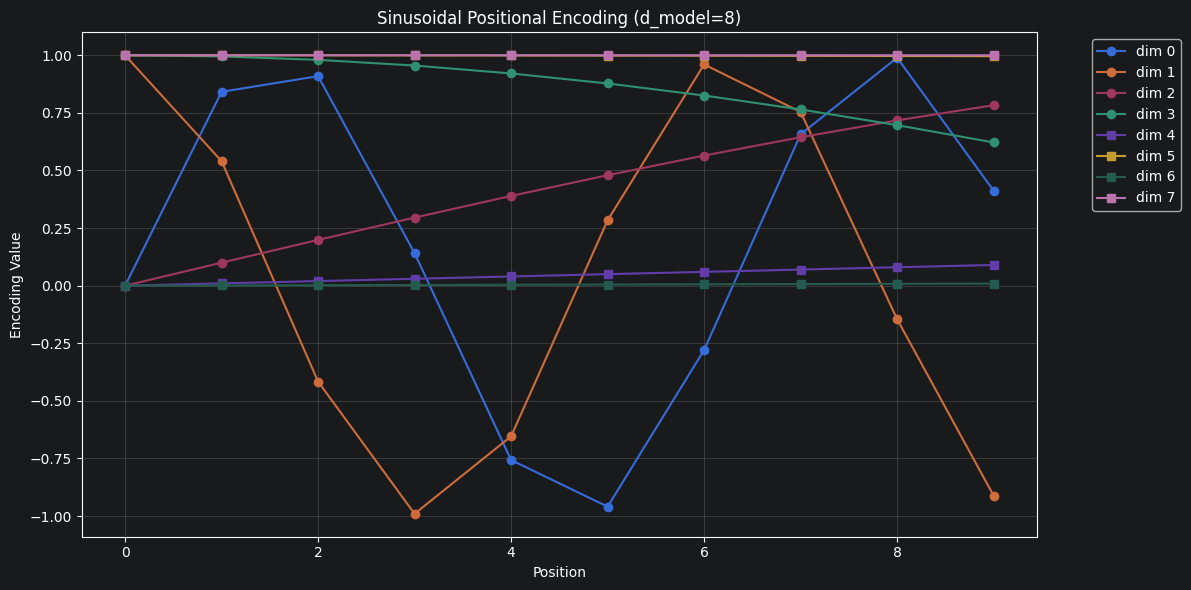

In [12]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12, 6))

for i in range(hidden_size):
    plt.plot(pe[:, i].numpy(), label=f'dim {i}', marker='o' if i < 4 else 's')

plt.xlabel('Position')
plt.ylabel('Encoding Value')
plt.title('Sinusoidal Positional Encoding (d_model=8)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Other**:
```
self.register_buffer('pe', pe.unsqueeze(0))
```
* a neural network module has three categories of stored tensors:
    * regular tensors: stays on CPU even when the model moves to GPU, breaking the forward pass, and are saved in `state_dict()`
    * `nn.Parameter`: saved in `state_dict` and updated by the optimizer--wasteful for positional encoding since gradients would be computed for values that never change
    * `self.register_buffer(name, tensor)` internally stores tensors in a special dict, and calls `__setattr__` so the buffer behaves as a regular attribute
* `unsqueeze(0)` adds a batch dimension to enable broadcasting, such that positional encoding is added to every sequence in the batch

```
def forward(x):
    return x + self.pe[:, :x.shape[1], :]
```
* `self.pe` shape: (1, max_seq_len, hidden_size)
* `x.shape`: (batch_size, seq_len, hidden_size) where `seq_len <= max_seq_len`
* `self.pe[:, :x.shape[1], :]` slices both the batch dimension and the feature dimension entirely, only restricting the sequence dimensions to match the input length
* broadcasting automatically expands to match batch dimensions

##### Learned Positional Encoding

In [ ]:
class LearnedPositionalEncoding(nn.Module):
    def __init__(self, hidden_size, max_seq_len=512):
        super().__init__()
        self.pos_embedding = nn.Embedding(max_seq_len, hidden_size)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0) # (1, seq_len)
        return x + self.pos_embeddings(positions)

In [22]:
hidden_size, max_seq_len = 8, 10

pos_emb = nn.Embedding(max_seq_len, hidden_size)
print("Weight matrix shape:", pos_emb.weight.shape)
print("Weight matrix (randomly initialized):\n", pos_emb.weight.data)

Weight matrix shape: torch.Size([10, 8])
Weight matrix (randomly initialized):
 tensor([[-0.1949,  1.3554,  0.0782, -1.1095, -0.4506, -0.6302,  1.9553,  0.0529],
        [-1.3661,  2.1110, -0.3485, -0.4176,  0.6164, -0.7090,  0.5707,  0.5607],
        [ 1.2844,  2.1018,  1.6596, -0.2808, -0.8853,  0.7741,  1.1720,  1.7318],
        [ 1.1409, -0.5069,  1.0471, -0.3041,  0.2375,  0.8015, -0.9421,  0.6931],
        [-1.1871, -0.0047, -0.4847, -0.6339, -0.5367,  0.1601,  0.1503, -0.5288],
        [ 0.0796, -0.0841,  0.8044, -0.7574, -0.3920,  2.0062,  0.0610,  1.2081],
        [ 0.5955, -0.2709, -0.7752,  0.6465, -0.0090, -0.3593, -0.7620,  0.9914],
        [ 0.2294, -0.3217, -0.6364,  2.0296, -1.1432,  0.7755,  0.1050, -0.5211],
        [ 0.8199, -1.1127, -0.5971, -0.1988,  0.0097, -0.0488,  2.1479, -1.2228],
        [ 1.2130, -0.3581,  0.8117,  1.2521, -0.5041,  0.9495,  0.4492,  0.3909]])


Unlike the sinusoidal version where every value is computed from a fixed formula, here every single number in the matrix is a parameter that will be updated by the optimizer during training via gradient descent. The model learns what makes a good positional representation for the specific task or data.

##### Interaction with Attention

##### RoPE (Rotary Position Embedding)

#### Transformer Block

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, hidden_size, num_heads, intermediate_size):
        super().__init__()
        self.attention = MultiHeadAttention(hidden_size, num_heads)
        self.ffn = FeedForward(hidden_size, intermediate_size)
        self.norm1 = LayerNorm(hidden_size)
        self.norm2 = LayerNorm(hidden_size)

    def forward(self, x):
        x = x + self.attention(self.norm1(x))
        x = x + self.ffn(self.norm2(x))
        return x

#### Attention Residuals